# 🎵 Spotify Tracks — EDA & Cleaning Pipeline
### DSC327 · Data Visualization Techniques:BDS 7
---
**Dataset:** `Spotify_Track_Dataset.csv` (114,001 rows × 21 columns)

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Light, clean, colourful style ─────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#FFFFFF',
    'axes.facecolor'   : '#F8F9FA',
    'axes.edgecolor'   : '#CCCCCC',
    'axes.labelcolor'  : '#333333',
    'xtick.color'      : '#555555',
    'ytick.color'      : '#555555',
    'text.color'       : '#222222',
    'grid.color'       : '#E0E0E0',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.7,
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.titlecolor'  : '#1a1a2e',
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})
sns.set_style('whitegrid')

# Palette
PAL      = ['#1DB954','#FF6B6B','#4ECDC4','#FFD93D','#6C5CE7',
            '#A29BFE','#FD79A8','#00B894','#E17055','#74B9FF']
GREEN    = '#1DB954'   # Spotify green
RED      = '#FF6B6B'
BLUE     = '#4ECDC4'
YELLOW   = '#FFD93D'
PURPLE   = '#6C5CE7'
ORANGE   = '#E17055'

print("Libraries imported — light theme active!")
print(f"    pandas {pd.__version__}  |  numpy {np.__version__}  |  seaborn {sns.__version__}")


Libraries imported — light theme active!
    pandas 2.2.2  |  numpy 1.25.2  |  seaborn 0.13.2


## 1️⃣  Load Dataset

In [25]:
df = pd.read_csv('Spotify_Track_Dataset.csv')

print(f"{'='*50}")
print(f"  Dataset loaded!")
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print(f"{'='*50}")
df.head(5)


  Dataset loaded!
  Rows    : 114,000
  Columns : 21


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 2️⃣  Initial Inspection

In [26]:
print("── Dtypes ──────────────────────────────────────────────")
print(df.dtypes.to_string())
print()
print("── Sample rows ─────────────────────────────────────────")
display(df.head(3))
print()
print("── Basic statistics ────────────────────────────────────")
df.describe(include='all').T


── Dtypes ──────────────────────────────────────────────
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object

── Sample rows ─────────────────────────────────────────


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,...,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,...,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,...,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic



── Basic statistics ────────────────────────────────────


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,NaN,NaN,NaN,56999.5,32909.109681,0.0,28499.75,56999.5,85499.25,113999.0
track_id,114000,89741,6S3JlDAGk3uu3NtZbPnuhS,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artists,113999,31437,The Beatles,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
album_name,113999,46589,Alternative Christmas 2022,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_name,113999,73608,Run Rudolph Run,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,114000.0,NaN,NaN,NaN,33.238535,22.305078,0.0,17.0,35.0,50.0,100.0
duration_ms,114000.0,NaN,NaN,NaN,228029.153114,107297.712645,0.0,174066.0,212906.0,261506.0,5237295.0
explicit,114000,2,False,104253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,114000.0,NaN,NaN,NaN,0.5668,0.173542,0.0,0.456,0.58,0.695,0.985
energy,114000.0,NaN,NaN,NaN,0.641383,0.251529,0.0,0.472,0.685,0.854,1.0


## 3️⃣  Missing Value Check

Columns with missing values : 3
Total missing cells         : 3  out of 2,394,000  (0.000%)

⚠️  Columns with missing values:
    Column  Missing Count  Missing %
track_name              1        0.0
album_name              1        0.0
   artists              1        0.0


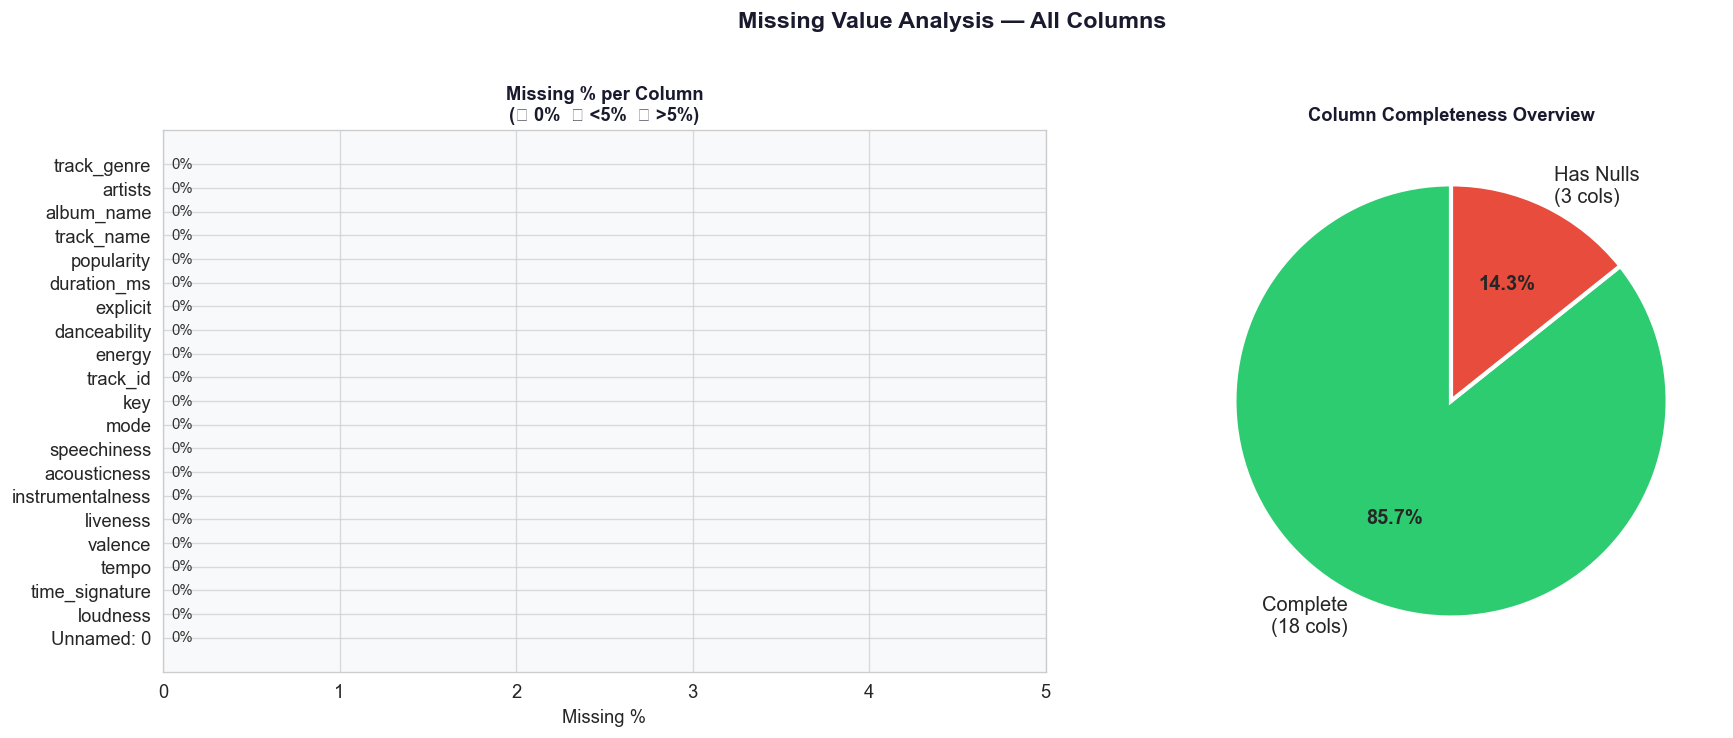

  ✅  Filled 'track_name' nulls with 'Unknown'
  ✅  Filled 'album_name' nulls with 'Unknown'
  ✅  Filled 'artists' nulls with 'Unknown'

Remaining missing values after fill: 0


In [27]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
mv_all = pd.DataFrame({'Column': missing.index,
                        'Missing Count': missing.values,
                        'Missing %':     missing_pct.values})
mv_all = mv_all.sort_values('Missing %', ascending=False).reset_index(drop=True)

# Summary print
cols_with_missing = mv_all[mv_all['Missing Count'] > 0]
print(f"Columns with missing values : {len(cols_with_missing)}")
print(f"Total missing cells         : {missing.sum():,}  out of {df.size:,}  ({missing.sum()/df.size*100:.3f}%)")
print()
if cols_with_missing.empty:
    print("✅  Dataset is COMPLETE — no missing values in any column!")
else:
    print("⚠️  Columns with missing values:")
    print(cols_with_missing.to_string(index=False))

# ── Always plot ALL columns so chart is always visible ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')
fig.suptitle('Missing Value Analysis — All Columns', fontsize=14,
             fontweight='bold', color='#1a1a2e', y=1.02)

# Left: horizontal bar for all columns
ax1 = axes[0]
colors = ['#E74C3C' if v > 5 else '#F39C12' if v > 0 else '#2ECC71'
          for v in mv_all['Missing %']]
bars = ax1.barh(mv_all['Column'], mv_all['Missing %'],
                color=colors, edgecolor='white', linewidth=0.6)
for bar, val in zip(bars, mv_all['Missing %']):
    label = f'{val:.2f}%' if val > 0 else '0%'
    ax1.text(bar.get_width() + 0.05,
             bar.get_y() + bar.get_height() / 2,
             label, va='center', fontsize=9, color='#333333')
ax1.set_xlabel('Missing %', fontsize=11)
ax1.set_title('Missing % per Column\n(🟢 0%  🟡 <5%  🔴 >5%)', fontsize=11)
ax1.set_facecolor('#F8F9FA')
ax1.set_xlim(0, max(mv_all['Missing %'].max() * 1.25, 5))
for sp in ax1.spines.values(): sp.set_edgecolor('#CCCCCC')

# Right: count of clean vs missing columns (always visible pie)
ax2 = axes[1]
n_clean   = int((mv_all['Missing Count'] == 0).sum())
n_missing = int((mv_all['Missing Count']  > 0).sum())
wedge_vals   = [n_clean, n_missing] if n_missing > 0 else [n_clean]
wedge_labels = [f'Complete\n({n_clean} cols)', f'Has Nulls\n({n_missing} cols)'] if n_missing > 0 else [f'All Complete\n({n_clean} cols)']
wedge_colors = ['#2ECC71', '#E74C3C'] if n_missing > 0 else ['#2ECC71']
wedges, texts, autotexts = ax2.pie(
    wedge_vals, labels=wedge_labels, colors=wedge_colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5},
    textprops={'fontsize': 12})
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(12)
ax2.set_title('Column Completeness Overview', fontsize=11)

plt.tight_layout()
plt.savefig('missing_values.png', bbox_inches='tight', facecolor='white', dpi=130)
plt.show()

# Handle missing values if any exist
if not cols_with_missing.empty:
    for col in cols_with_missing['Column']:
        if df[col].dtype in ['float64', 'int64']:
            fill_val = df[col].median()
            df[col].fillna(fill_val, inplace=True)
            print(f"  ✅  Filled '{col}' ({cols_with_missing[cols_with_missing['Column']==col]['Missing Count'].values[0]} nulls) with median = {fill_val:.3f}")
        else:
            df[col].fillna('Unknown', inplace=True)
            print(f"  ✅  Filled '{col}' nulls with 'Unknown'")
    print(f"\nRemaining missing values after fill: {df.isnull().sum().sum()}")


## 4️⃣  Duplicate Detection & Removal

In [28]:
n_dup    = df.duplicated().sum()
n_dup_id = df.duplicated(subset=['track_id']).sum()

print(f"Exact duplicate rows   : {n_dup:,}")
print(f"Duplicate track_id rows: {n_dup_id:,}")

if n_dup > 0:
    df.drop_duplicates(inplace=True)
    print(f"✅  Removed {n_dup:,} exact duplicates. Shape → {df.shape}")
else:
    print("✅  No exact duplicates found.")

if n_dup_id > 0:
    df.drop_duplicates(subset=['track_id'], inplace=True)
    print(f"✅  Removed duplicate track_ids. Shape → {df.shape}")
else:
    print("✅  No duplicate track_ids found.")


Exact duplicate rows   : 0
Duplicate track_id rows: 24,259
✅  No exact duplicates found.
✅  Removed duplicate track_ids. Shape → (89741, 21)


## 5️⃣  Data Type Corrections

In [29]:
print("── BEFORE ──────────────────────────────────────────────")
print(df.dtypes.to_string())

# explicit: string TRUE/FALSE → bool
if df['explicit'].dtype == object:
    df['explicit'] = df['explicit'].str.strip().str.upper().map(
        {'TRUE': True, 'FALSE': False})
    df['explicit'] = df['explicit'].astype(bool)
    print("\n✅  'explicit'  →  bool")

# numeric columns
numeric_cols = ['popularity','duration_ms','danceability','energy','key',
                'loudness','mode','speechiness','acousticness',
                'instrumentalness','liveness','valence','tempo','time_signature']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# drop NaNs introduced by coercion
before_shape = df.shape
df.dropna(subset=numeric_cols, inplace=True)
print(f"✅  Rows dropped by coercion NaN: {before_shape[0]-df.shape[0]:,}")

# int types for categorical-numeric columns
for col in ['mode','key','time_signature']:
    df[col] = df[col].astype(int)

# handy derived column
df['duration_sec'] = (df['duration_ms'] / 1000).round(1)

print("\n── AFTER ───────────────────────────────────────────────")
print(df.dtypes.to_string())
print(f"\nShape: {df.shape}")


── BEFORE ──────────────────────────────────────────────
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
✅  Rows dropped by coercion NaN: 0

── AFTER ───────────────────────────────────────────────
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy    

## 6️⃣  Value-Range Sanity Check

In [30]:
VALID_RANGES = {
    'popularity':       (0, 100),
    'danceability':     (0.0, 1.0),
    'energy':           (0.0, 1.0),
    'loudness':         (-60, 4),
    'speechiness':      (0.0, 1.0),
    'acousticness':     (0.0, 1.0),
    'instrumentalness': (0.0, 1.0),
    'liveness':         (0.0, 1.0),
    'valence':          (0.0, 1.0),
    'tempo':            (0, 300),
    'duration_ms':      (10_000, 1_800_000),
}

print(f"{'Column':<22} {'Min':>9} {'Max':>9}  {'Valid Range':<18}  {'Out-of-range':>12}")
print('─'*76)
total_bad = 0
for col, (lo, hi) in VALID_RANGES.items():
    mn, mx = df[col].min(), df[col].max()
    bad    = int(((df[col] < lo) | (df[col] > hi)).sum())
    total_bad += bad
    flag = '⚠️ ' if bad > 0 else '✅'
    print(f"{flag} {col:<20} {mn:>9.3f} {mx:>9.3f}  [{lo}, {hi}]  {bad:>12,}")

print('─'*76)
print(f"Total out-of-range values: {total_bad:,}")

# Remove
for col, (lo, hi) in VALID_RANGES.items():
    before = len(df)
    df     = df[(df[col] >= lo) & (df[col] <= hi)]
    removed = before - len(df)
    if removed > 0:
        print(f"  Removed {removed:,} rows with invalid '{col}'")

print(f"\n✅  Shape after range filter: {df.shape}")


Column                       Min       Max  Valid Range         Out-of-range
────────────────────────────────────────────────────────────────────────────
✅ popularity               0.000   100.000  [0, 100]             0
✅ danceability             0.000     0.985  [0.0, 1.0]             0
✅ energy                   0.000     1.000  [0.0, 1.0]             0
⚠️  loudness               -49.531     4.532  [-60, 4]             1
✅ speechiness              0.000     0.965  [0.0, 1.0]             0
✅ acousticness             0.000     0.996  [0.0, 1.0]             0
✅ instrumentalness         0.000     1.000  [0.0, 1.0]             0
✅ liveness                 0.000     1.000  [0.0, 1.0]             0
✅ valence                  0.000     0.995  [0.0, 1.0]             0
✅ tempo                    0.000   243.372  [0, 300]             0
⚠️  duration_ms              0.000 5237295.000  [10000, 1800000]            36
────────────────────────────────────────────────────────────────────────────
Tota

## 7️⃣  Outlier Detection & Removal (IQR Method)
### 7a — Boxplots BEFORE Outlier Removal
> Orange flier dots = outliers. Notice the spread on several columns.


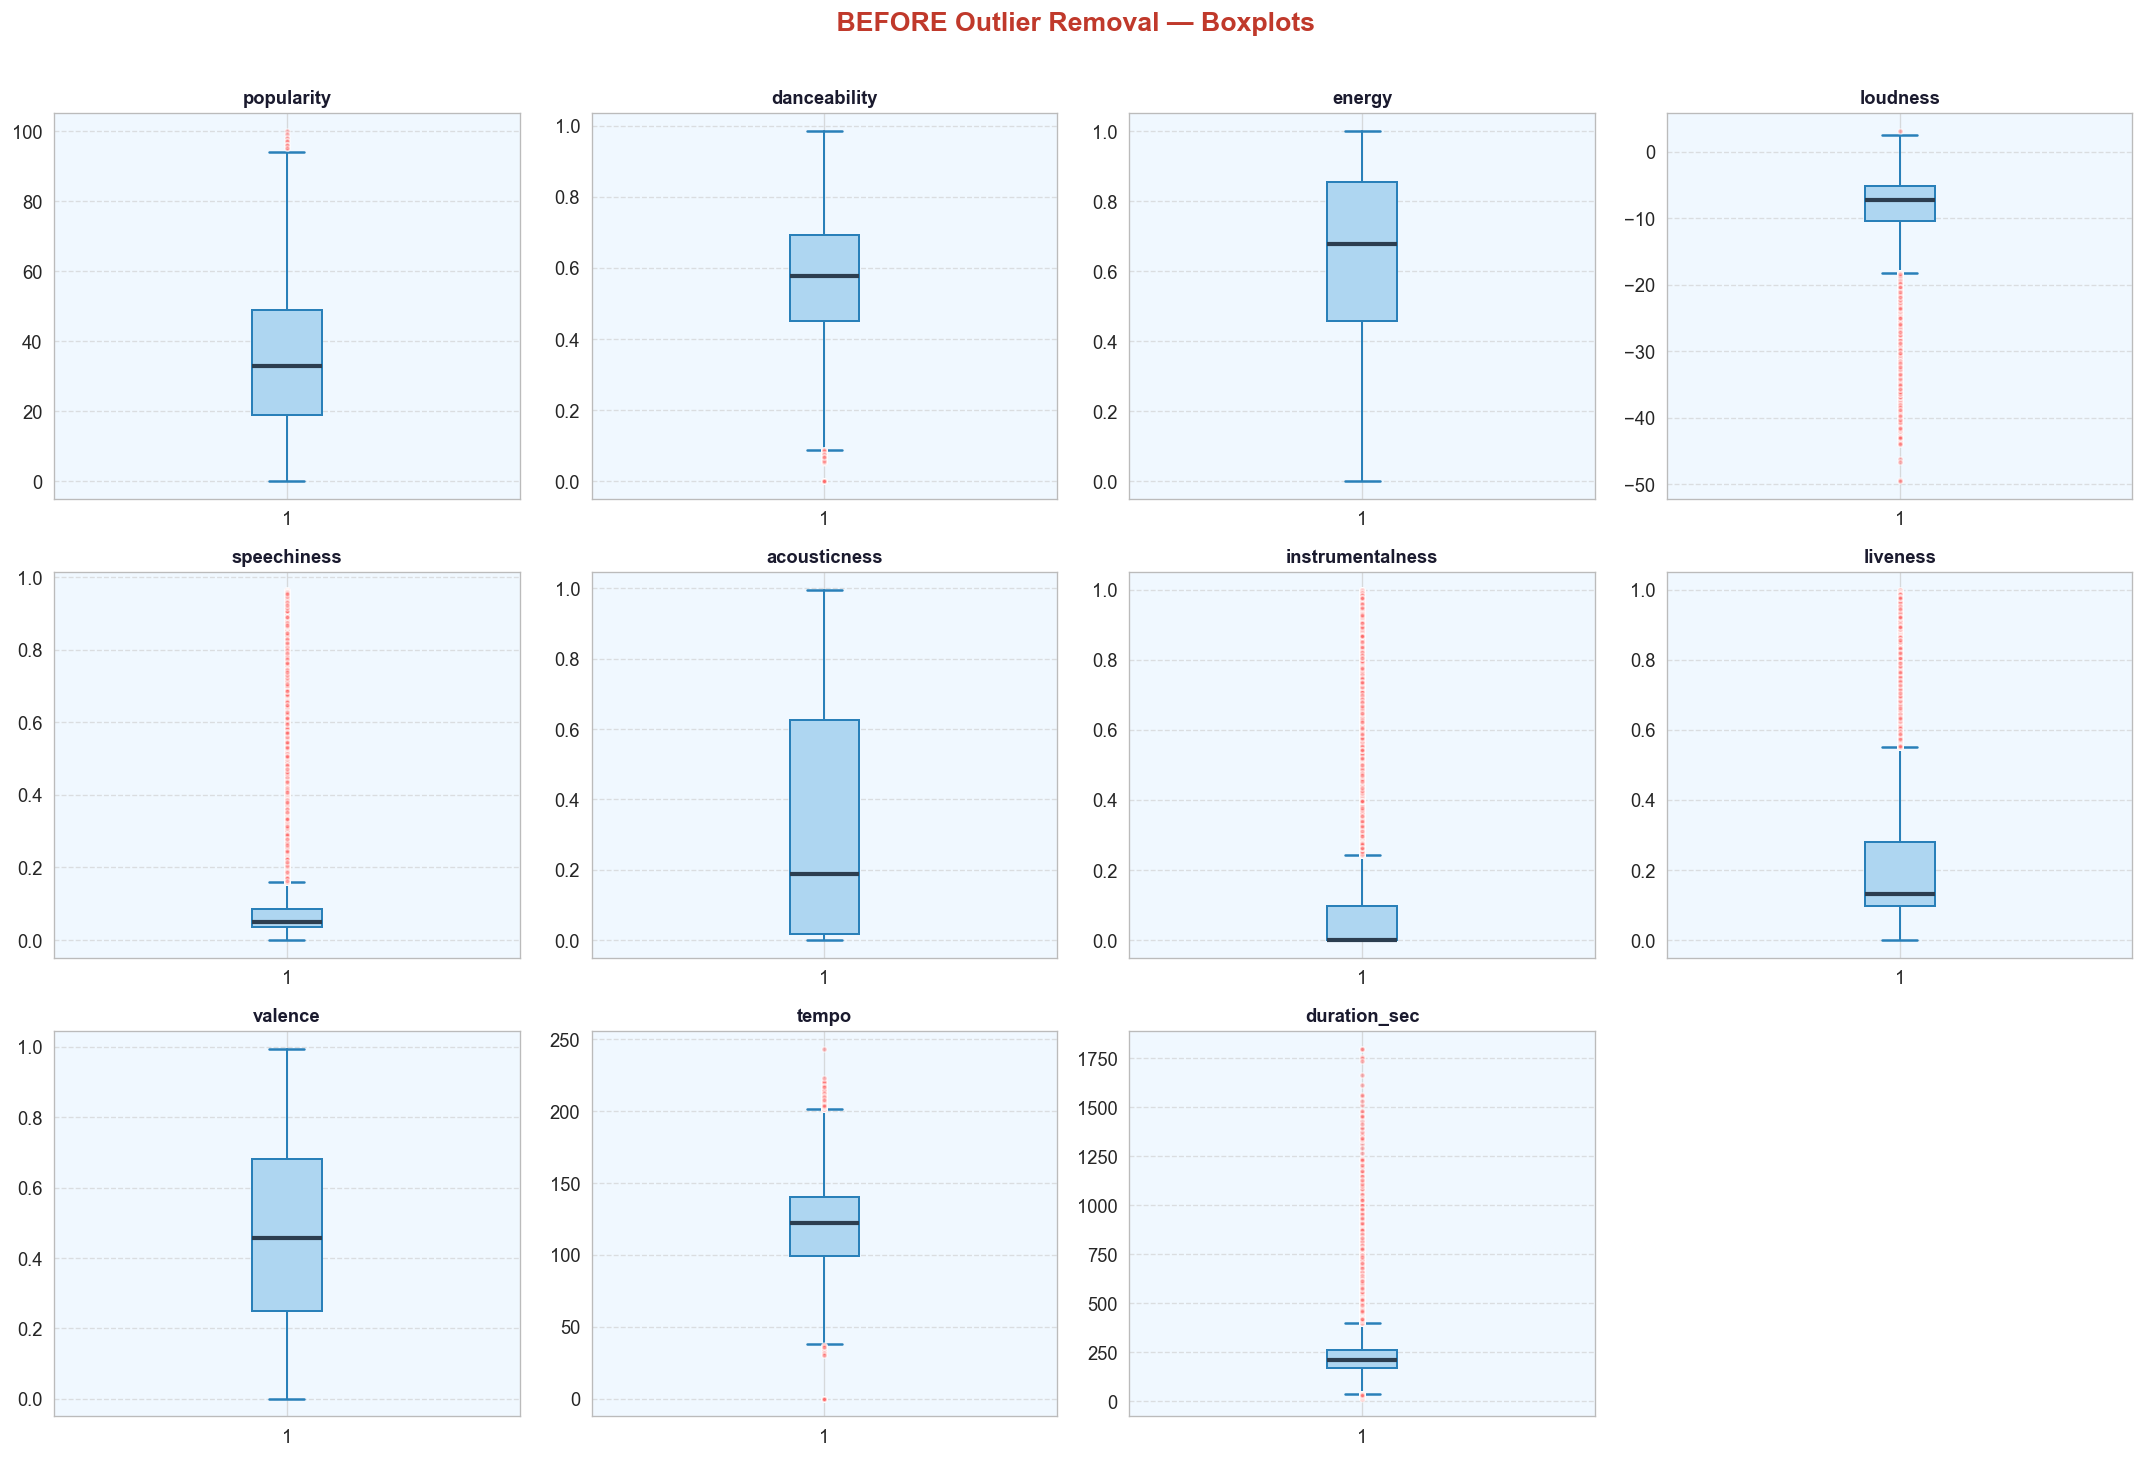

🔴  Red dots = outliers (IQR method).  Will be removed in next cell.


In [31]:
# ALL continuous features that could have outliers
ALL_FEATS = ['popularity','danceability','energy','loudness',
             'speechiness','acousticness','instrumentalness',
             'liveness','valence','tempo','duration_sec']

df_before_iqr = df.copy()   # keep a snapshot for comparison

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle(' BEFORE Outlier Removal — Boxplots', fontsize=16,
             fontweight='bold', color='#c0392b', y=1.01)
fig.patch.set_facecolor('white')

for idx, col in enumerate(ALL_FEATS):
    ax = axes[idx//4][idx%4]
    bp = ax.boxplot(df[col].dropna(), patch_artist=True, notch=False,
                    medianprops  =dict(color='#2c3e50',  linewidth=2.5),
                    boxprops     =dict(facecolor='#AED6F1', color='#2980B9', linewidth=1.2),
                    whiskerprops =dict(color='#2980B9',  linewidth=1.2),
                    capprops     =dict(color='#2980B9',  linewidth=1.5),
                    flierprops   =dict(marker='o', markerfacecolor=RED,
                                       markeredgecolor='white', alpha=0.5,
                                       markersize=3, linestyle='none'))
    ax.set_title(col, fontsize=11, pad=6)
    ax.set_facecolor('#F0F8FF')
    for sp in ax.spines.values(): sp.set_edgecolor('#BBBBBB')
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)

axes[2][3].set_visible(False)
plt.tight_layout()
plt.savefig('boxplots_before.png', bbox_inches='tight', facecolor='white', dpi=130)
plt.show()
print("🔴  Red dots = outliers (IQR method).  Will be removed in next cell.")


### 7b — IQR Outlier Removal (applied to ALL continuous features)

In [32]:
# Apply IQR removal to EVERY continuous feature shown in the boxplots
# This ensures before/after plots look visibly different
IQR_COLS = ['popularity','danceability','energy','loudness',
            'speechiness','acousticness','instrumentalness',
            'liveness','valence','tempo','duration_sec']

rows_before = len(df)

print(f"{'Column':<22} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Lower':>8} {'Upper':>8}  {'Removed':>9}")
print('─'*82)

for col in IQR_COLS:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = int(((df[col] < lower) | (df[col] > upper)).sum())
    df    = df[(df[col] >= lower) & (df[col] <= upper)]
    print(f"  {col:<20} {Q1:>8.3f} {Q3:>8.3f} {IQR:>8.3f} {lower:>8.3f} {upper:>8.3f}  {n_out:>9,}")

rows_after   = len(df)
rows_removed = rows_before - rows_after
print('─'*82)
print(f"\nRows BEFORE : {rows_before:,}")
print(f"Rows AFTER  : {rows_after:,}")
print(f"Rows removed: {rows_removed:,}  ({rows_removed/rows_before*100:.2f}%)")
print("\n Outlier removal complete.")


Column                       Q1       Q3      IQR    Lower    Upper    Removed
──────────────────────────────────────────────────────────────────────────────────
  popularity             19.000   49.000   30.000  -26.000   94.000         11
  danceability            0.450    0.692    0.242    0.087    1.055        469
  energy                  0.460    0.854    0.394   -0.131    1.445          0
  loudness              -10.269   -5.098    5.171  -18.026    2.659      4,809
  speechiness             0.036    0.089    0.053   -0.044    0.168      9,777
  acousticness            0.013    0.566    0.553   -0.816    1.395          0
  instrumentalness        0.000    0.047    0.047   -0.071    0.118     16,417
  liveness                0.099    0.282    0.183   -0.176    0.557      4,216
  valence                 0.316    0.720    0.404   -0.290    1.326          0
  tempo                 100.020  140.613   40.593   39.130  201.502        216
  duration_sec          177.700  254.700   77.00

### 7c — Boxplots AFTER Outlier Removal

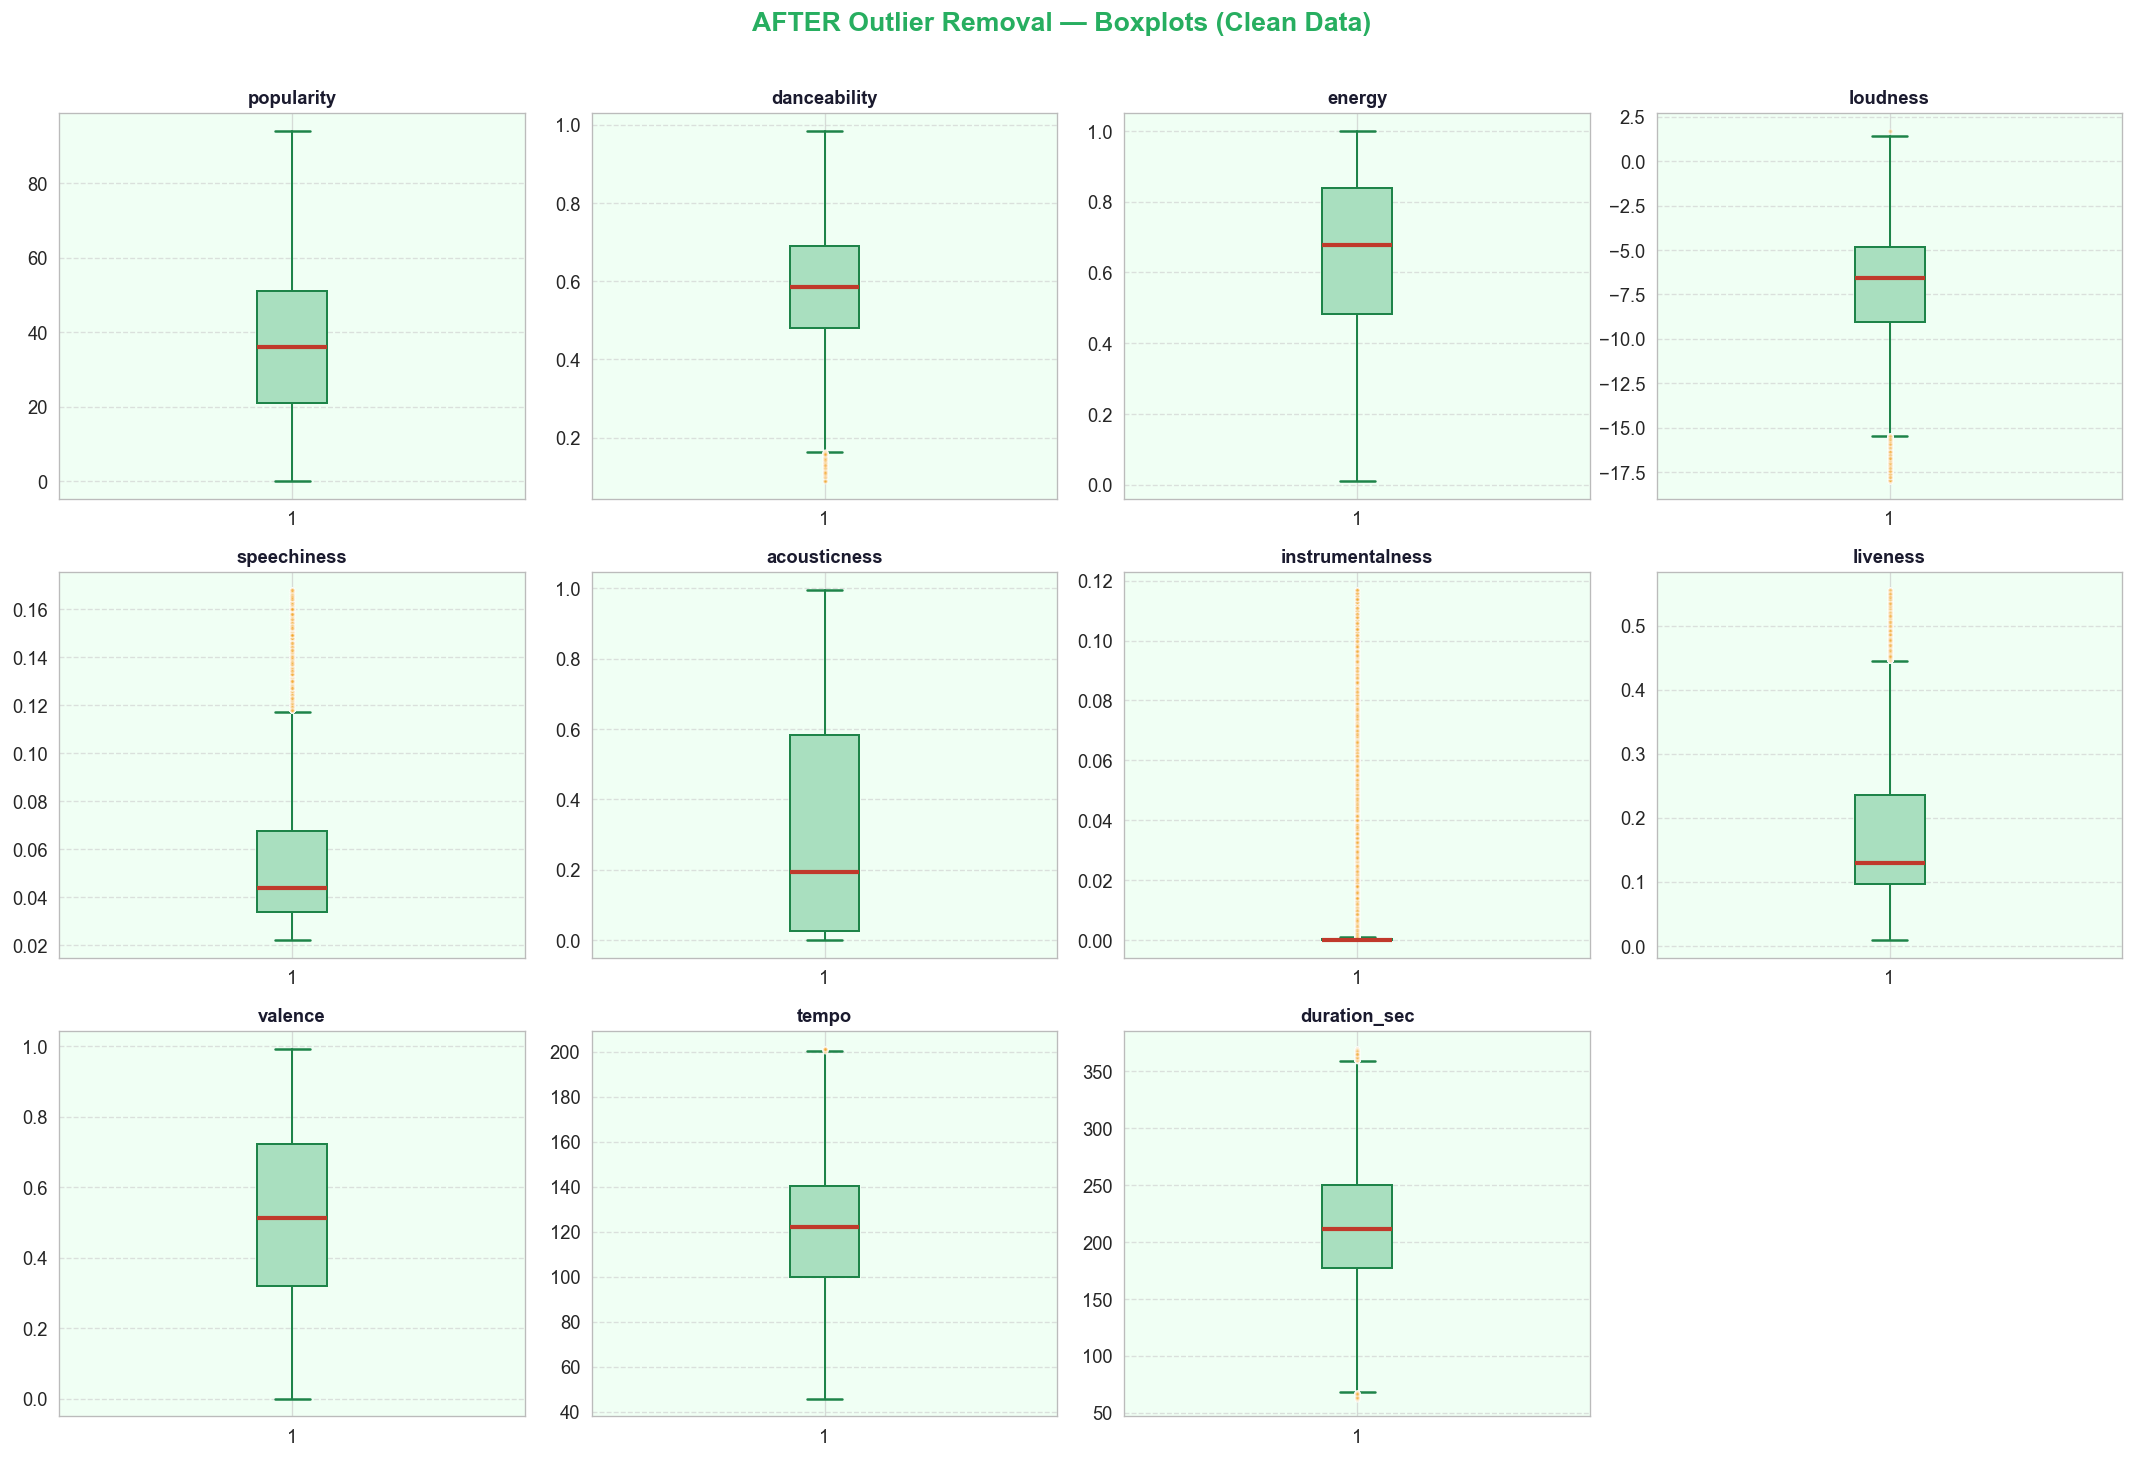

 Boxes are tighter, extreme fliers gone. Compare with BEFORE above.


In [33]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('AFTER Outlier Removal — Boxplots (Clean Data)', fontsize=16,
             fontweight='bold', color='#27ae60', y=1.01)
fig.patch.set_facecolor('white')

for idx, col in enumerate(ALL_FEATS):
    ax = axes[idx//4][idx%4]
    ax.boxplot(df[col].dropna(), patch_artist=True, notch=False,
               medianprops  =dict(color='#c0392b',  linewidth=2.5),
               boxprops     =dict(facecolor='#A9DFBF', color='#1E8449', linewidth=1.2),
               whiskerprops =dict(color='#1E8449',  linewidth=1.2),
               capprops     =dict(color='#1E8449',  linewidth=1.5),
               flierprops   =dict(marker='o', markerfacecolor='#F39C12',
                                   markeredgecolor='white', alpha=0.4,
                                   markersize=2.5, linestyle='none'))
    ax.set_title(col, fontsize=11, pad=6)
    ax.set_facecolor('#F0FFF4')
    for sp in ax.spines.values(): sp.set_edgecolor('#BBBBBB')
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)

axes[2][3].set_visible(False)
plt.tight_layout()
plt.savefig('boxplots_after.png', bbox_inches='tight', facecolor='white', dpi=130)
plt.show()
print(" Boxes are tighter, extreme fliers gone. Compare with BEFORE above.")


### 7d — Side-by-Side Before vs After (Key Columns)

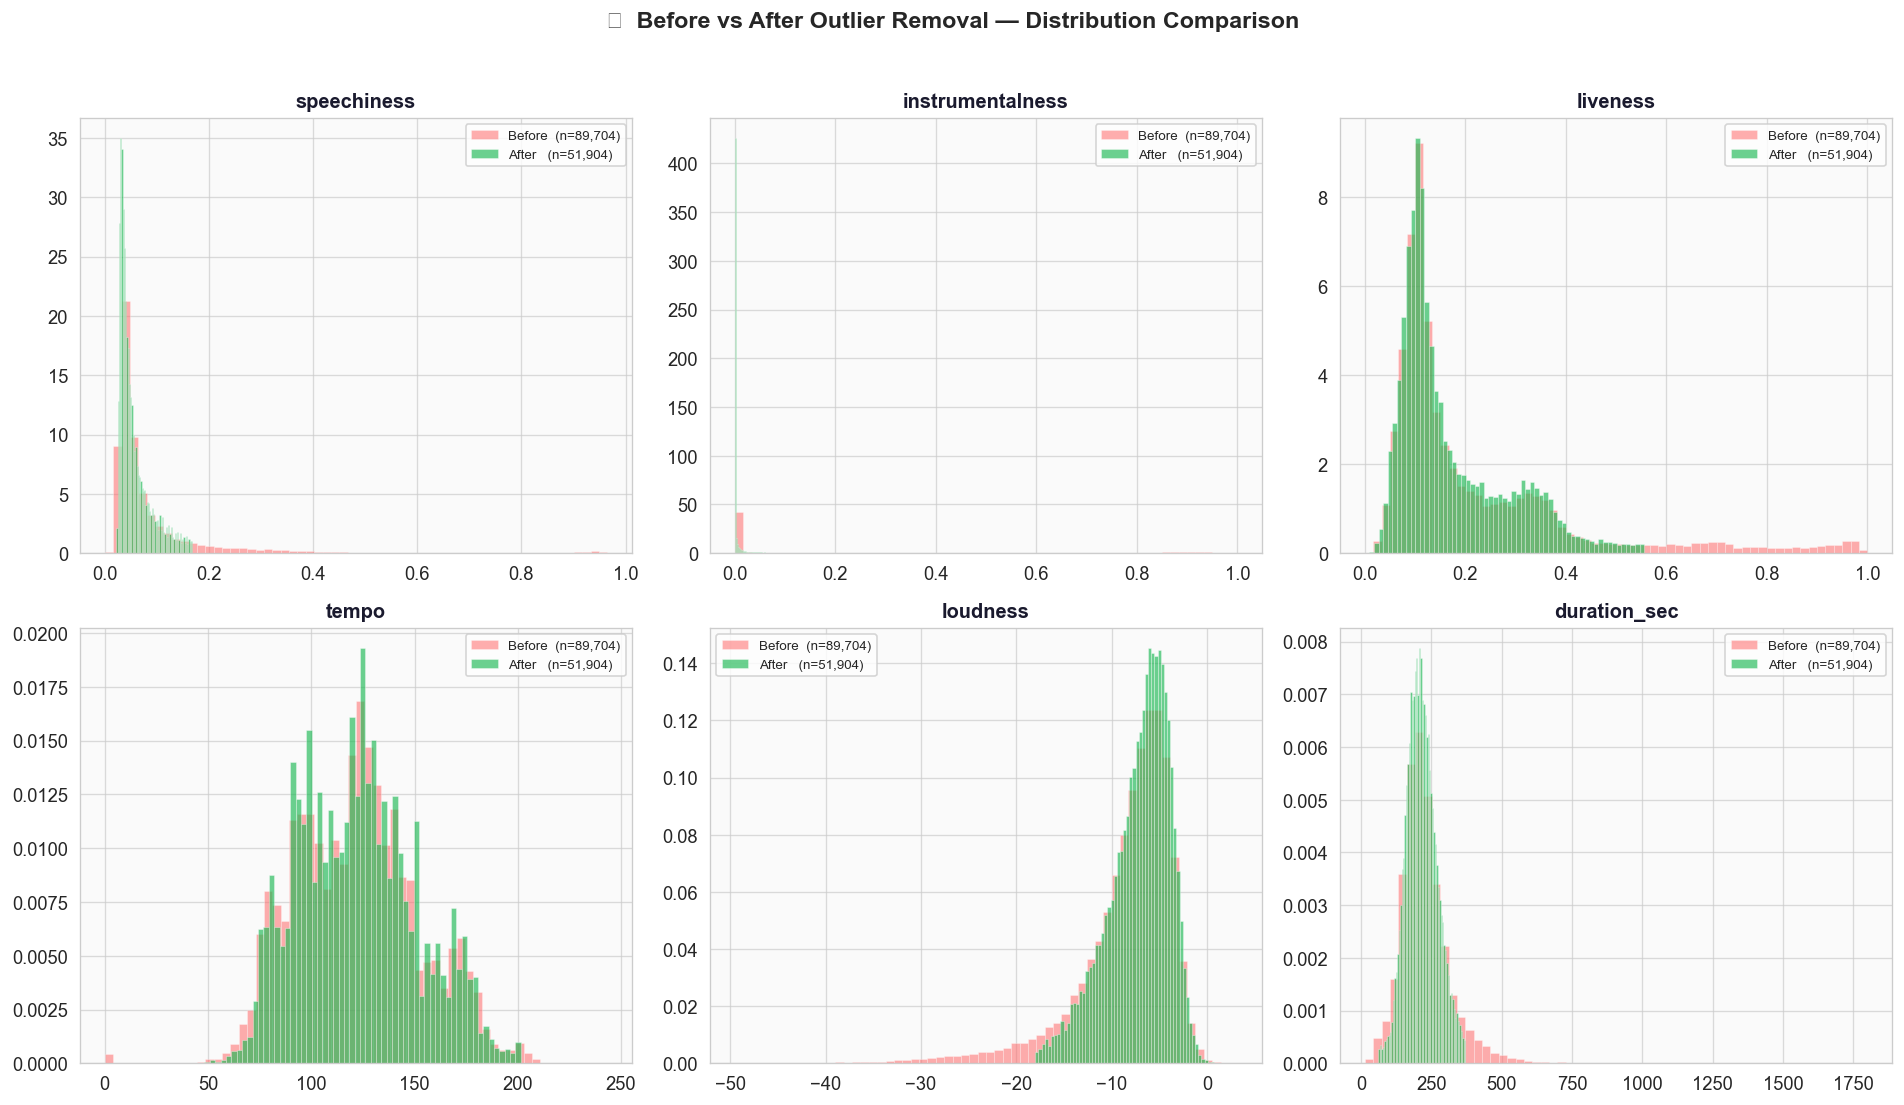

🔴 Red = BEFORE  |  🟢 Green = AFTER
Notice the long tails in red are removed — distributions are now much tighter.


In [34]:
COMPARE_COLS = ['speechiness','instrumentalness','liveness',
                'tempo','loudness','duration_sec']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('🔍  Before vs After Outlier Removal — Distribution Comparison',
             fontsize=14, fontweight='bold', y=1.02)
fig.patch.set_facecolor('white')

for idx, col in enumerate(COMPARE_COLS):
    ax = axes[idx//3][idx%3]

    before_data = df_before_iqr[col].dropna()
    after_data  = df[col].dropna()

    ax.hist(before_data, bins=60, color=RED,   alpha=0.55, density=True,
            label=f'Before  (n={len(before_data):,})', edgecolor='white', linewidth=0.3)
    ax.hist(after_data,  bins=60, color=GREEN, alpha=0.65, density=True,
            label=f'After   (n={len(after_data):,})',  edgecolor='white', linewidth=0.3)

    ax.set_title(col, fontsize=12)
    ax.set_facecolor('#FAFAFA')
    ax.legend(fontsize=8, framealpha=0.8)
    for sp in ax.spines.values(): sp.set_edgecolor('#CCCCCC')

plt.tight_layout()
plt.savefig('before_after_comparison.png', bbox_inches='tight', facecolor='white', dpi=130)
plt.show()
print("🔴 Red = BEFORE  |  🟢 Green = AFTER")
print("Notice the long tails in red are removed — distributions are now much tighter.")


## 8️⃣  Correlation Heatmap (Cleaned Data)

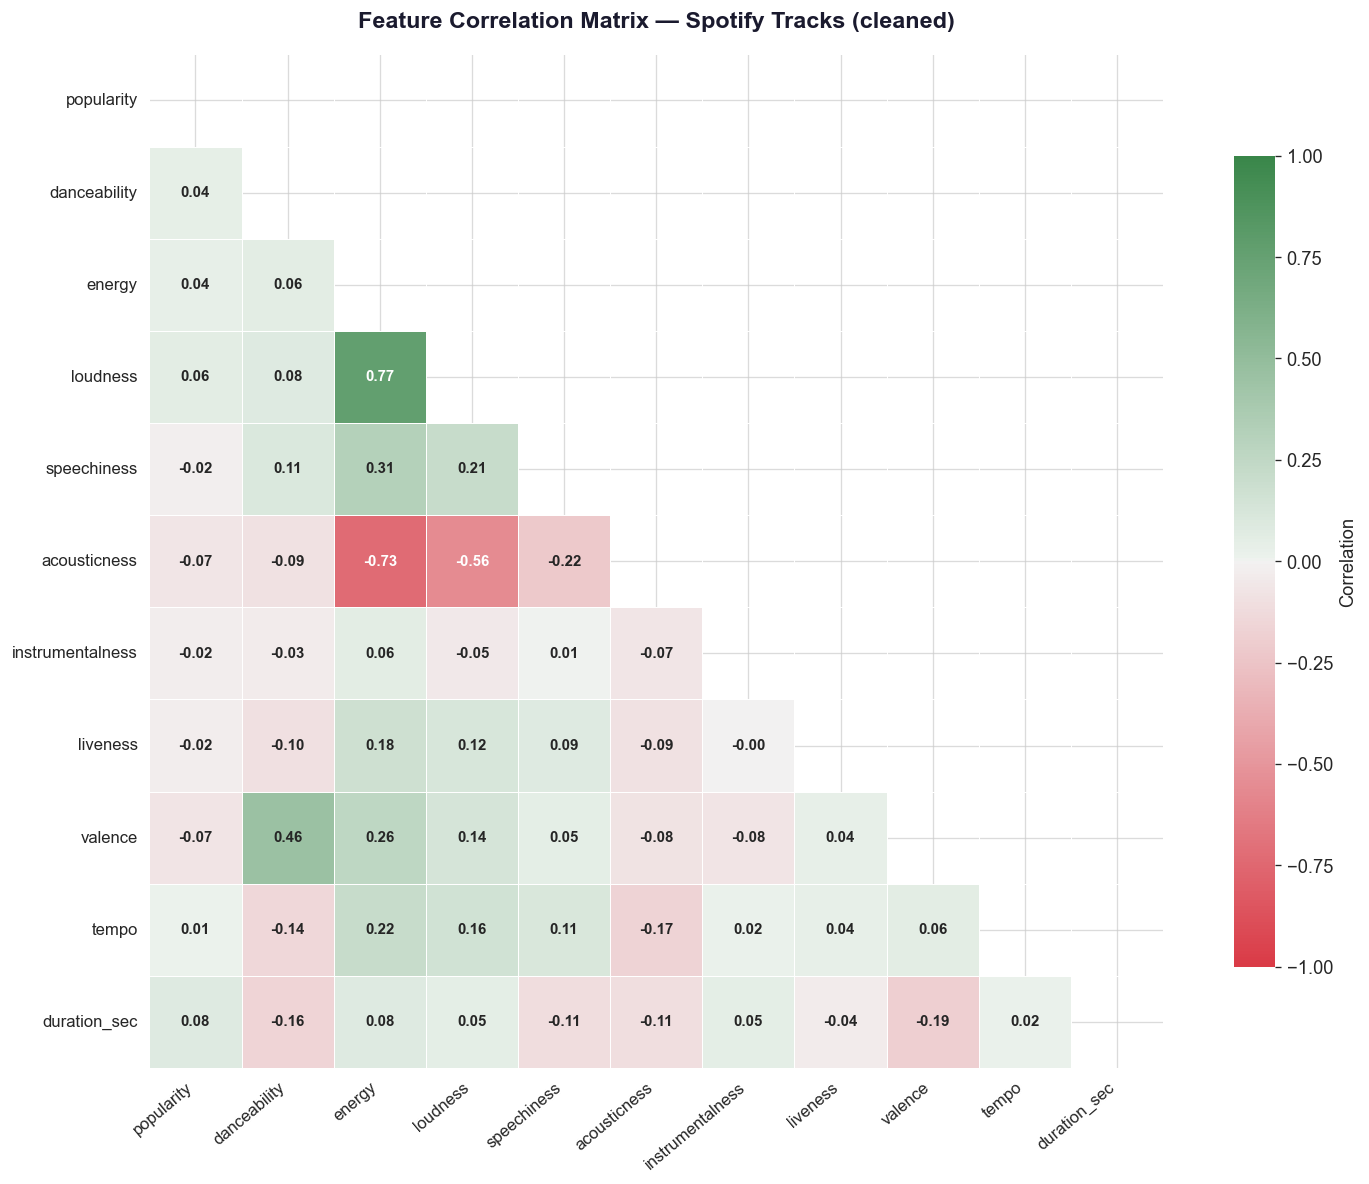


── Top 10 Feature Correlations (|r| descending) ───────────────
  loudness             ↔  energy                r=+0.773  ███████████████
  acousticness         ↔  energy                r=-0.731  ██████████████
  acousticness         ↔  loudness              r=-0.557  ███████████
  valence              ↔  danceability          r=+0.459  █████████
  speechiness          ↔  energy                r=+0.314  ██████
  valence              ↔  energy                r=+0.264  █████
  acousticness         ↔  speechiness           r=-0.224  ████
  tempo                ↔  energy                r=+0.217  ████
  speechiness          ↔  loudness              r=+0.213  ████
  duration_sec         ↔  valence               r=-0.194  ███


In [35]:
corr_cols = ['popularity','danceability','energy','loudness','speechiness',
             'acousticness','instrumentalness','liveness','valence','tempo','duration_sec']
corr  = df[corr_cols].corr()
mask  = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor('white')

cmap = sns.diverging_palette(10, 133, as_cmap=True)
hm   = sns.heatmap(corr, mask=mask, cmap=cmap, center=0, vmin=-1, vmax=1,
                   annot=True, fmt='.2f',
                   annot_kws={'size':9, 'weight':'bold'},
                   linewidths=0.6, linecolor='white',
                   square=True, ax=ax,
                   cbar_kws={'label':'Correlation', 'shrink':0.8})
hm.set_xticklabels(hm.get_xticklabels(), rotation=40, ha='right', fontsize=10)
hm.set_yticklabels(hm.get_yticklabels(), rotation=0, fontsize=10)
ax.set_title('Feature Correlation Matrix — Spotify Tracks (cleaned)',
             fontsize=14, fontweight='bold', pad=16, color='#1a1a2e')
ax.set_facecolor('white')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', facecolor='white', dpi=130)
plt.show()

# Top correlations
corr_pairs = (corr.where(~mask).stack()
                  .reset_index()
                  .rename(columns={'level_0':'F1','level_1':'F2',0:'r'}))
corr_pairs['abs_r'] = corr_pairs['r'].abs()
print("\n── Top 10 Feature Correlations (|r| descending) ───────────────")
for _, row in corr_pairs.sort_values('abs_r',ascending=False).head(10).iterrows():
    bar = '█' * int(abs(row['r'])*20)
    print(f"  {row['F1']:<20} ↔  {row['F2']:<20}  r={row['r']:+.3f}  {bar}")


## 9️⃣  Genre Distribution (EDA)

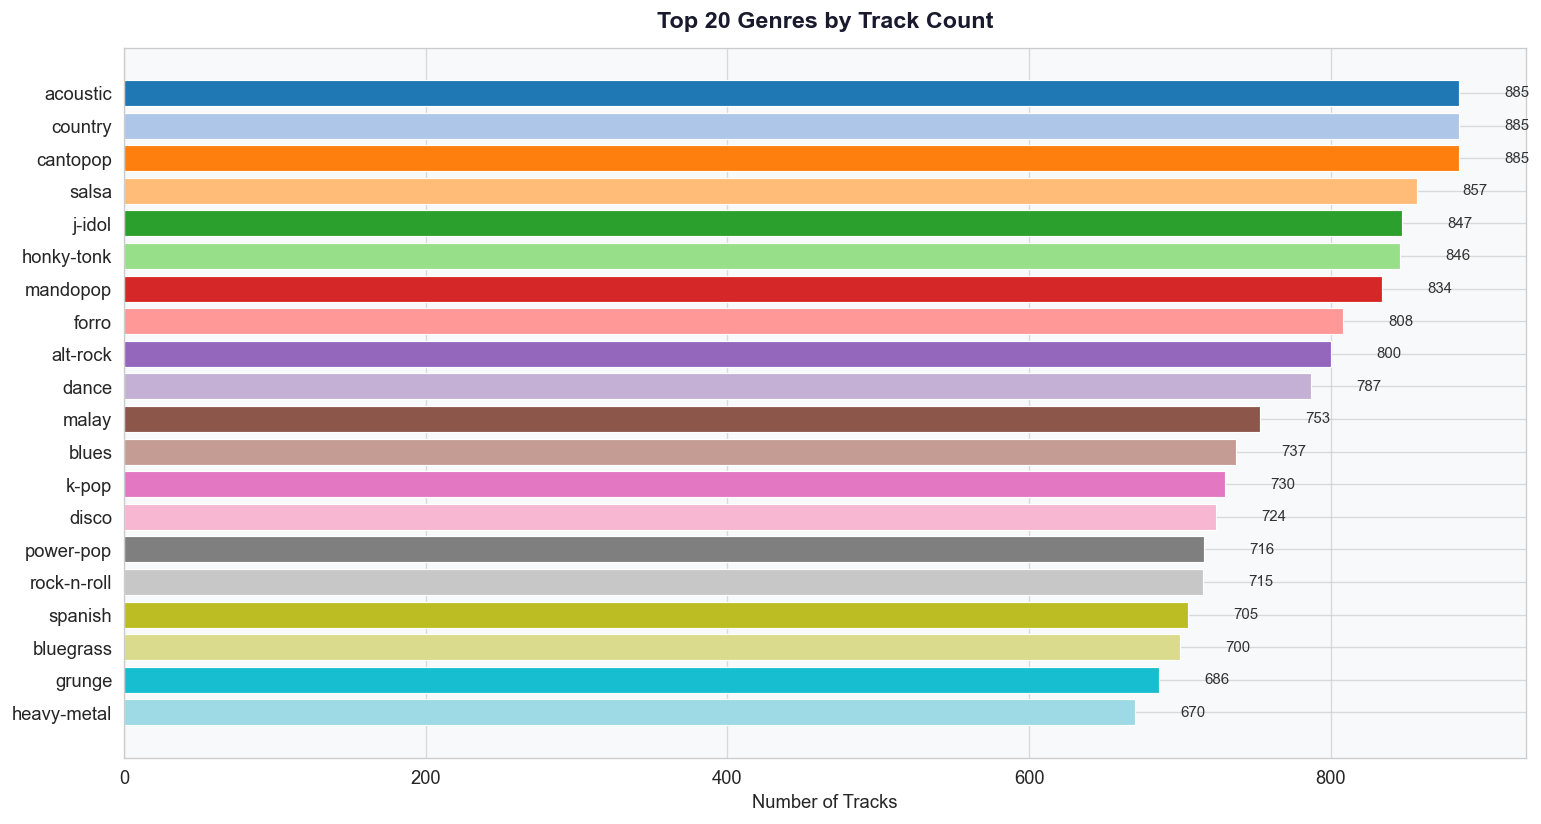

Total unique genres: 113
Top genre          : acoustic  (885 tracks)


In [36]:
genre_counts = df['track_genre'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('white')

colors = plt.cm.tab20(np.linspace(0, 1, len(genre_counts)))
bars   = ax.barh(genre_counts.index[::-1], genre_counts.values[::-1],
                 color=colors[::-1], edgecolor='white', linewidth=0.7)
for bar, val in zip(bars, genre_counts.values[::-1]):
    ax.text(bar.get_width()+30, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, color='#333')

ax.set_xlabel('Number of Tracks', fontsize=11)
ax.set_title('Top 20 Genres by Track Count', fontsize=14,
             fontweight='bold', color='#1a1a2e', pad=12)
ax.set_facecolor('#F8F9FA')
plt.tight_layout()
plt.savefig('genre_distribution.png', bbox_inches='tight', facecolor='white', dpi=130)
plt.show()
print(f"Total unique genres: {df['track_genre'].nunique()}")
print(f"Top genre          : {genre_counts.index[0]}  ({genre_counts.iloc[0]:,} tracks)")


## 🔟  Audio Feature Averages by Top 10 Genres

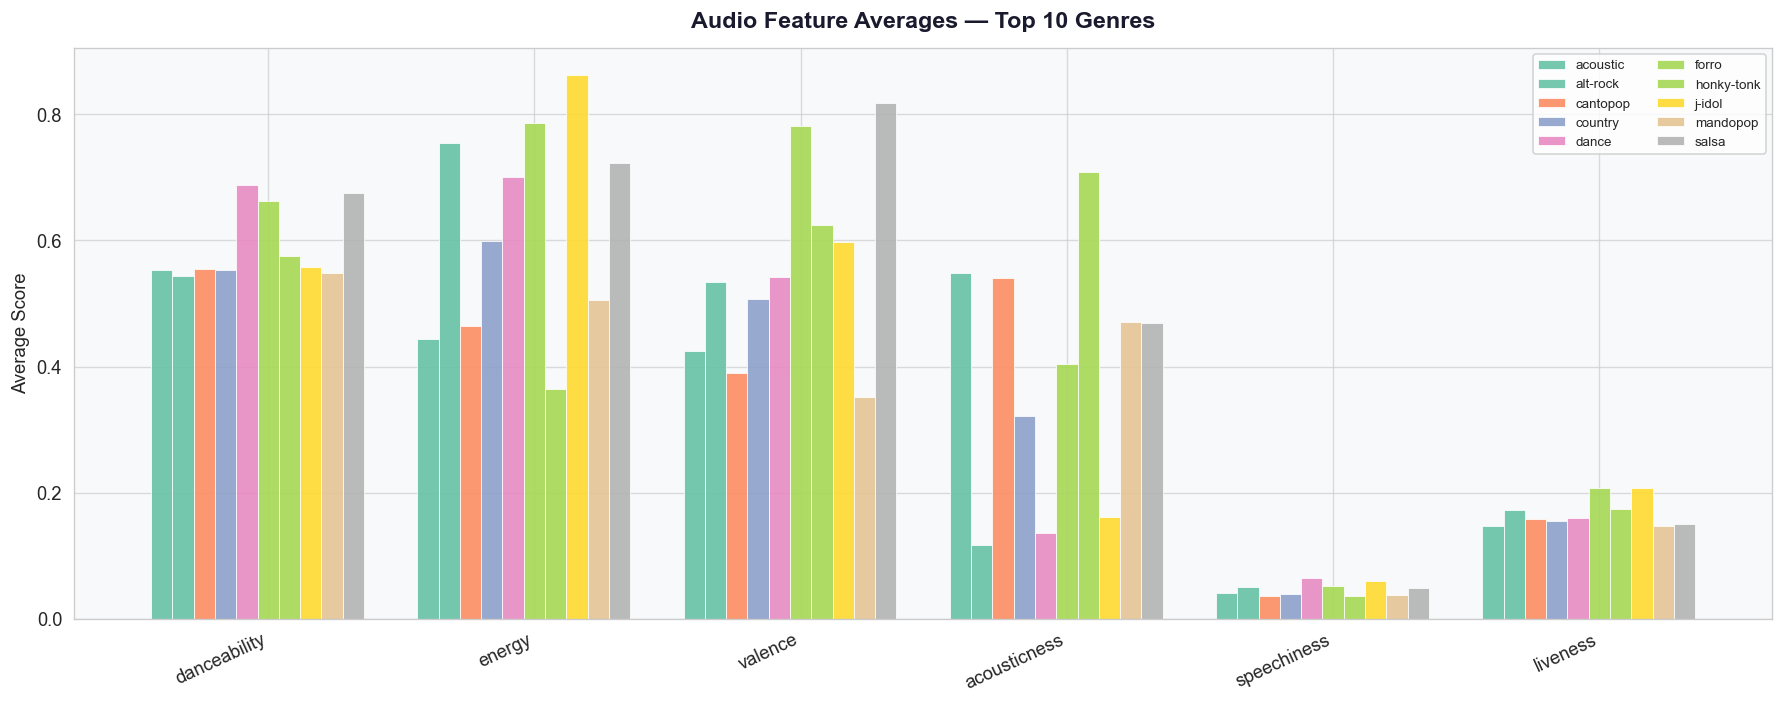

In [37]:
top10_genres = df['track_genre'].value_counts().head(10).index
df_top       = df[df['track_genre'].isin(top10_genres)]
feat_cols    = ['danceability','energy','valence',
                'acousticness','speechiness','liveness']
genre_means  = df_top.groupby('track_genre')[feat_cols].mean()

fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor('white')

x     = np.arange(len(feat_cols))
width = 0.08
cmap  = plt.cm.Set2

for i, (genre, row) in enumerate(genre_means.iterrows()):
    ax.bar(x + i*width, row[feat_cols], width,
           label=genre, color=cmap(i/len(genre_means)),
           alpha=0.9, edgecolor='white', linewidth=0.5)

ax.set_xticks(x + width*len(genre_means)/2)
ax.set_xticklabels(feat_cols, rotation=25, ha='right', fontsize=11)
ax.set_ylabel('Average Score', fontsize=11)
ax.set_title('Audio Feature Averages — Top 10 Genres', fontsize=14,
             fontweight='bold', color='#1a1a2e', pad=12)
ax.legend(loc='upper right', fontsize=8, framealpha=0.8, ncol=2)
ax.set_facecolor('#F8F9FA')
plt.tight_layout()
plt.savefig('features_by_genre.png', bbox_inches='tight', facecolor='white', dpi=130)
plt.show()


## 1️⃣1️⃣  Popularity Distribution & Mode Comparison

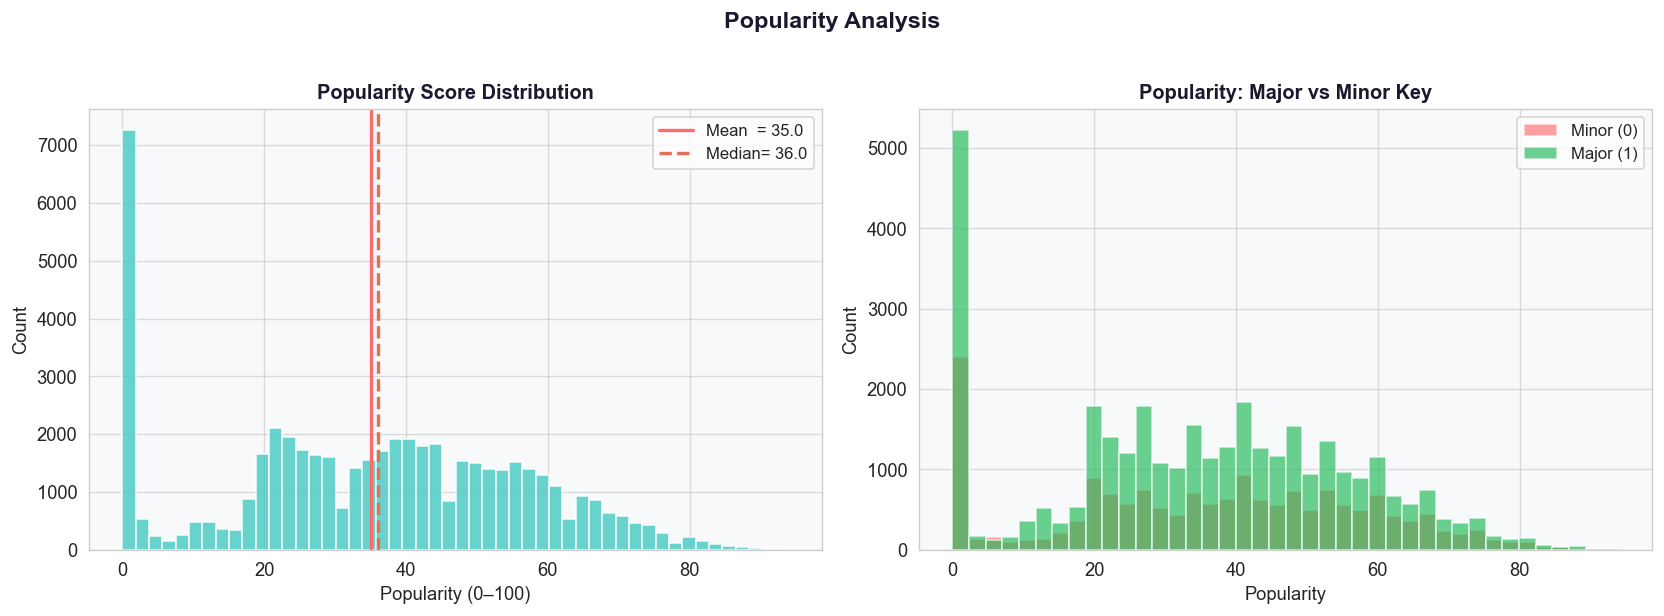

  Avg popularity — Minor: 36.14
  Avg popularity — Major: 34.45


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

# Popularity histogram
ax = axes[0]
ax.hist(df['popularity'], bins=50, color=BLUE, edgecolor='white', alpha=0.85)
ax.axvline(df['popularity'].mean(),   color=RED,    lw=2,   label=f"Mean  = {df['popularity'].mean():.1f}")
ax.axvline(df['popularity'].median(), color=ORANGE, lw=2, ls='--', label=f"Median= {df['popularity'].median():.1f}")
ax.set_title('Popularity Score Distribution', fontsize=12)
ax.set_xlabel('Popularity (0–100)')
ax.set_ylabel('Count')
ax.legend(fontsize=10)
ax.set_facecolor('#F8F9FA')

# Major vs Minor
ax2 = axes[1]
for val, clr, lbl in [(0, RED, 'Minor (0)'), (1, GREEN, 'Major (1)')]:
    ax2.hist(df[df['mode']==val]['popularity'], bins=40,
             alpha=0.65, label=lbl, color=clr, edgecolor='white')
ax2.set_title('Popularity: Major vs Minor Key', fontsize=12)
ax2.set_xlabel('Popularity')
ax2.set_ylabel('Count')
ax2.legend(fontsize=10)
ax2.set_facecolor('#F8F9FA')

plt.suptitle('Popularity Analysis', fontsize=14, fontweight='bold',
             color='#1a1a2e', y=1.02)
plt.tight_layout()
plt.savefig('popularity_analysis.png', bbox_inches='tight', facecolor='white', dpi=130)
plt.show()

for mode_val, label in [(0,'Minor'),(1,'Major')]:
    mean_pop = df[df['mode']==mode_val]['popularity'].mean()
    print(f"  Avg popularity — {label}: {mean_pop:.2f}")


## 1️⃣2️⃣  Explicit vs Non-Explicit Analysis

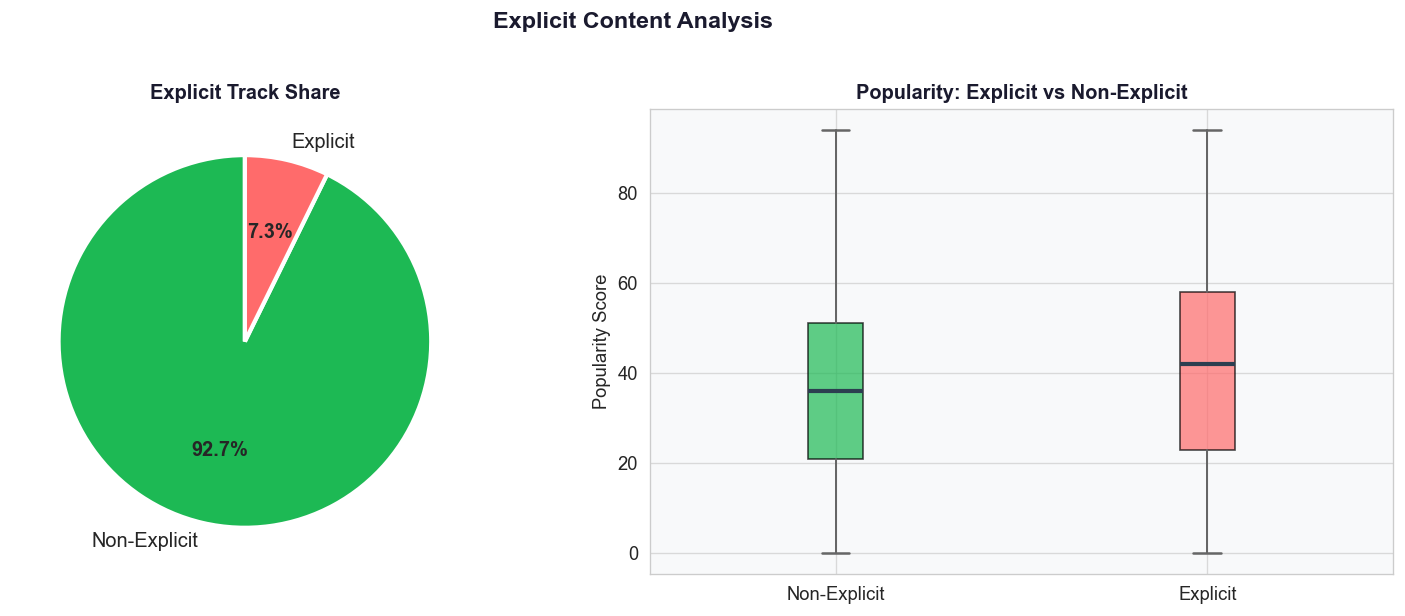

  Non-Explicit   : 48,127 tracks  |  Avg popularity = 34.68
  Explicit       :  3,777 tracks  |  Avg popularity = 39.32


In [39]:
exp_counts = df['explicit'].value_counts()
exp_labels = ['Non-Explicit','Explicit']
exp_colors = [GREEN, RED]
exp_vals   = [exp_counts.get(False,0), exp_counts.get(True,0)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')

# Pie chart
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    exp_vals, labels=exp_labels, colors=exp_colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2.5},
    textprops={'fontsize':12})
for at in autotexts: at.set_fontweight('bold')
ax.set_title('Explicit Track Share', fontsize=12)

# Boxplot popularity comparison
ax2 = axes[1]
data_bp = [df[df['explicit']==False]['popularity'],
           df[df['explicit']==True ]['popularity']]
bp = ax2.boxplot(data_bp, patch_artist=True, notch=False, labels=exp_labels,
                 medianprops =dict(color='#2c3e50', linewidth=2.5),
                 whiskerprops=dict(color='#666', linewidth=1.2),
                 capprops    =dict(color='#666', linewidth=1.5),
                 flierprops  =dict(marker='o', alpha=0.3, markersize=3, linestyle='none'))
for patch, clr in zip(bp['boxes'], exp_colors):
    patch.set_facecolor(clr); patch.set_alpha(0.7)
ax2.set_title('Popularity: Explicit vs Non-Explicit', fontsize=12)
ax2.set_ylabel('Popularity Score')
ax2.set_facecolor('#F8F9FA')

plt.suptitle('Explicit Content Analysis', fontsize=14, fontweight='bold',
             color='#1a1a2e', y=1.02)
plt.tight_layout()
plt.savefig('explicit_analysis.png', bbox_inches='tight', facecolor='white', dpi=130)
plt.show()

for label, flag in [('Non-Explicit', False),('Explicit', True)]:
    cnt = exp_counts.get(flag, 0)
    mean_p = df[df['explicit']==flag]['popularity'].mean()
    print(f"  {label:<15}: {cnt:>6,} tracks  |  Avg popularity = {mean_p:.2f}")


## 1️⃣3️⃣  Energy vs Loudness Scatter (coloured by Popularity)

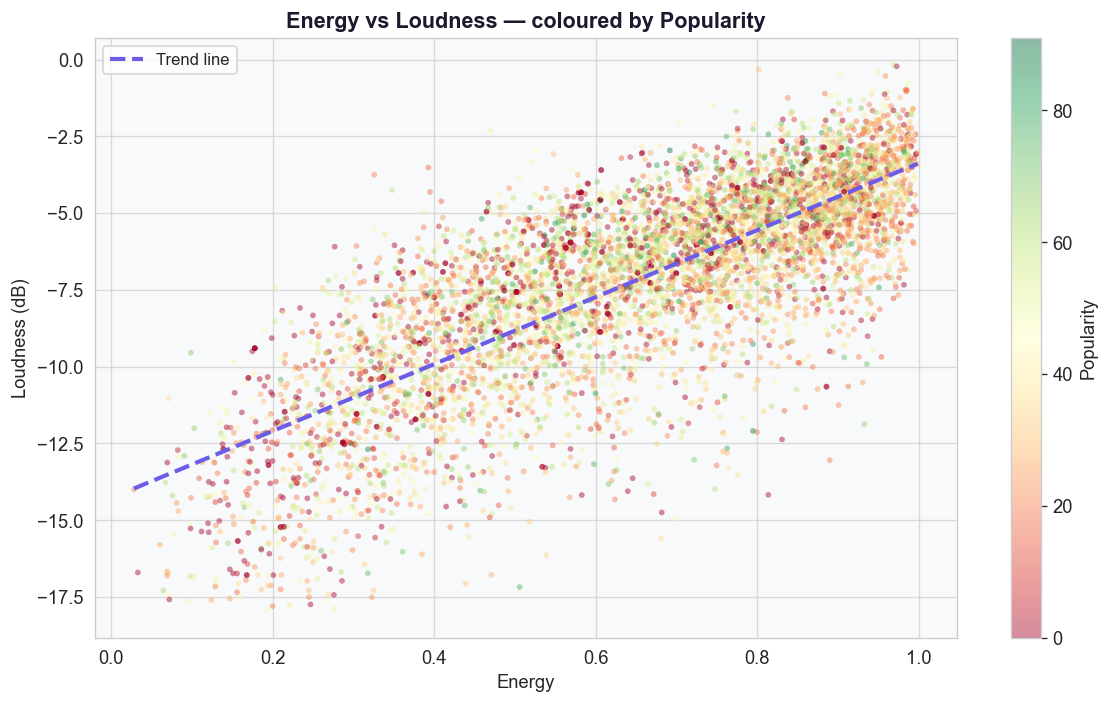

Pearson r (Energy ↔ Loudness) = 0.7732


In [40]:
sample = df.sample(min(6000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8F9FA')

sc = ax.scatter(sample['energy'], sample['loudness'],
                c=sample['popularity'], cmap='RdYlGn',
                alpha=0.45, s=12, edgecolors='none')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Popularity', fontsize=11)

# Trendline
z  = np.polyfit(sample['energy'], sample['loudness'], 1)
xs = np.linspace(sample['energy'].min(), sample['energy'].max(), 200)
ax.plot(xs, np.poly1d(z)(xs), color=PURPLE, lw=2.5, ls='--', label='Trend line')

ax.set_xlabel('Energy', fontsize=11)
ax.set_ylabel('Loudness (dB)', fontsize=11)
ax.set_title('Energy vs Loudness — coloured by Popularity', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('energy_vs_loudness.png', bbox_inches='tight', facecolor='white', dpi=130)
plt.show()

print(f"Pearson r (Energy ↔ Loudness) = {df['energy'].corr(df['loudness']):.4f}")


## 1️⃣4️⃣  Danceability vs Valence — Mood Map

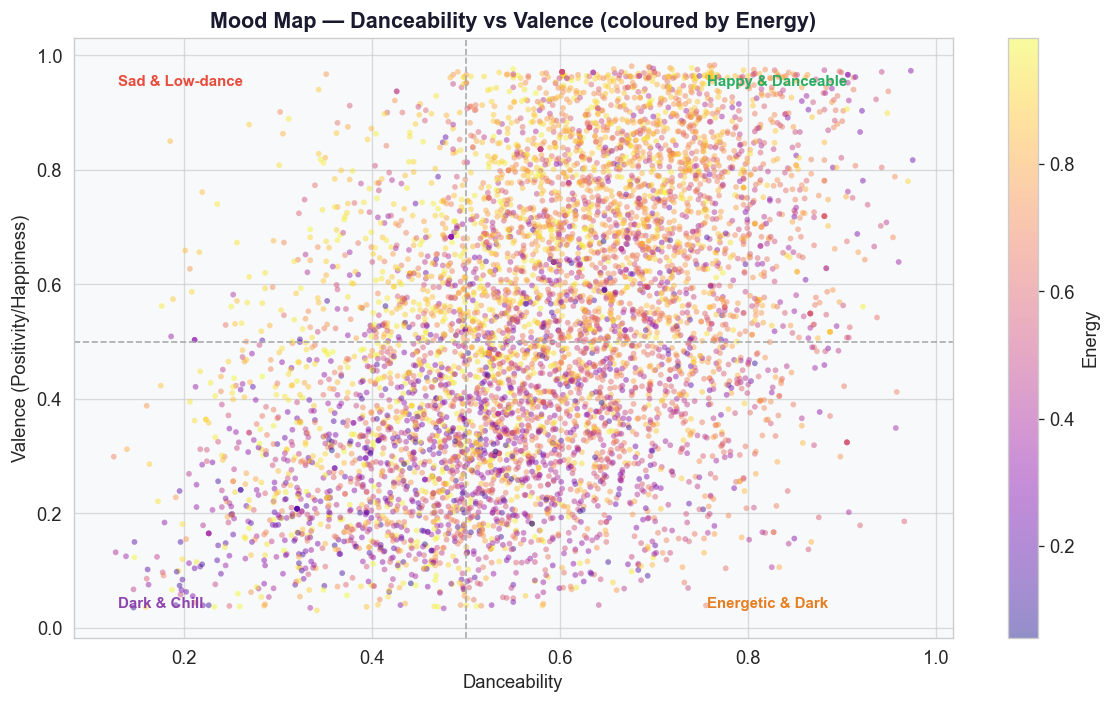

Danceability ↔ Valence  r = 0.4594
Energy       ↔ Valence  r = 0.2643


In [41]:
sample2 = df.sample(min(6000, len(df)), random_state=7)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8F9FA')

sc = ax.scatter(sample2['danceability'], sample2['valence'],
                c=sample2['energy'], cmap='plasma',
                alpha=0.45, s=12, edgecolors='none')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Energy', fontsize=11)

# Quadrant labels
ax.axhline(0.5, color='#AAAAAA', lw=1, ls='--')
ax.axvline(0.5, color='#AAAAAA', lw=1, ls='--')
for tx, ty, label, clr in [
        (0.05, 0.92, 'Sad & Low-dance',  '#e74c3c'),
        (0.72, 0.92, 'Happy & Danceable','#27ae60'),
        (0.05, 0.05, 'Dark & Chill',     '#8e44ad'),
        (0.72, 0.05, 'Energetic & Dark', '#e67e22')]:
    ax.text(tx, ty, label, transform=ax.transAxes, fontsize=9,
            color=clr, fontweight='bold')

ax.set_xlabel('Danceability', fontsize=11)
ax.set_ylabel('Valence (Positivity/Happiness)', fontsize=11)
ax.set_title('Mood Map — Danceability vs Valence (coloured by Energy)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dance_vs_valence.png', bbox_inches='tight', facecolor='white', dpi=130)
plt.show()

print(f"Danceability ↔ Valence  r = {df['danceability'].corr(df['valence']):.4f}")
print(f"Energy       ↔ Valence  r = {df['energy'].corr(df['valence']):.4f}")


---
## 🎯  8 Analysis Questions for Web Dashboard (D3.js)

Each question is answered by an **interactive D3.js chart** on the final web dashboard.

| # | Question | Chart Type | Key Columns |
|---|----------|-----------|-------------|
| Q1 | Which genres dominate Spotify in track count & avg popularity? | Grouped horizontal bar + dropdown | `track_genre`, `popularity` |
| Q2 | How do energy & loudness relate — and does popularity play a role? | Interactive scatter (zoom + tooltip) | `energy`, `loudness`, `popularity` |
| Q3 | What is the mood landscape? (Danceability vs Valence by Genre) | Bubble scatter (x=dance, y=valence, size=pop) | `danceability`, `valence`, `popularity`, `track_genre` |
| Q4 | Which audio feature best predicts popularity? | Animated sorted bar (correlation with popularity) | all numeric features vs `popularity` |
| Q5 | How do genre audio fingerprints compare? | Radar / spider chart per genre | `acousticness`, `energy`, `danceability`, `valence`, `speechiness` |
| Q6 | Are explicit tracks more popular — does it vary by genre? | Stacked/grouped bar + genre filter | `explicit`, `popularity`, `track_genre` |
| Q7 | What is the BPM distribution across genres? | Violin / box chart (interactive hover) | `tempo`, `track_genre` |
| Q8 | Do longer tracks tend to be more or less popular? | Scatter + brush filter (duration vs popularity) | `duration_sec`, `popularity`, `track_genre` |

---


## Export Cleaned CSV

In [42]:
out_path = 'Spotify_Cleaned.csv'
df.to_csv(out_path, index=False)

import os
size_mb = os.path.getsize(out_path) / (1024*1024)

print(f" Saved  →  '{out_path}'")
print(f"   Rows    : {len(df):,}")
print(f"   Columns : {df.shape[1]}")
print(f"   Size    : {size_mb:.2f} MB")
print()
print("📌  Load in D3.js dashboard with:")
print("    d3.csv('Spotify_Cleaned.csv').then(data => { ... })")


 Saved  →  'Spotify_Cleaned.csv'
   Rows    : 51,904
   Columns : 22
   Size    : 9.02 MB

📌  Load in D3.js dashboard with:
    d3.csv('Spotify_Cleaned.csv').then(data => { ... })
